# 13. Biclustering (Co-Clustering)

## 🎯 Objetivos
- Entender el problema de biclustering: agrupar simultáneamente filas y columnas.
- Diferenciarlo del clustering tradicional.
- Aplicar métodos de scikit-learn: `SpectralCoclustering` y `SpectralBiclustering`.
- Interpretar resultados y reordenar matrices.
- Explorar usos: expresión génica, recomendadores, análisis de consumo.
- Evaluar biclusters con medidas simples (densidad, cobertura).

---
## 1. Motivación 💡
Clustering tradicional agrupa solo instancias (filas). Sin embargo, en muchos contextos existe **estructura conjunta** entre subconjuntos de filas y columnas:
- Genes y condiciones experimentales.
- Usuarios y subconjuntos de productos.
- Estudiantes y subconjuntos de ejercicios.

Un bicluster identifica un submatriz donde los valores tienen algún patrón coherente (p.ej. mayor intensidad, correlación, etc.).

### Ejemplos de uso de biclustering en la práctica:

1. Análisis de expresión génica

    - Descubrir subconjuntos de genes que se comportan de forma similar bajo ciertos subconjuntos de condiciones experimentales.
    - Permite identificar módulos funcionales o rutas biológicas activas solo en ciertos contextos.

2. Sistemas de recomendación

    - Encontrar grupos de usuarios que tienen preferencias similares sobre subconjuntos específicos de productos.
    - Útil para segmentar usuarios y personalizar recomendaciones en plataformas de e-commerce, streaming, etc.

3. Análisis de consumo o ventas

    - Detectar patrones de compra conjunta entre grupos de clientes y grupos de productos.
    - Ayuda a diseñar promociones dirigidas o a optimizar el inventario.

4. Educación y aprendizaje personalizado

    - Identificar grupos de estudiantes que presentan patrones de acierto/error similares en subconjuntos de ejercicios o temas.
    - Facilita la detección de dificultades comunes y la personalización de la enseñanza.

5. Análisis de encuestas o cuestionarios

    - Agrupar preguntas y encuestados para descubrir patrones de respuesta coherentes en subconjuntos de preguntas.

6. Procesamiento de texto y minería de opiniones

    - Encontrar subconjuntos de documentos y términos que coaparecen frecuentemente, útil en análisis de temas o sentimientos.

7. Bioinformática y química

    - Identificar patrones en matrices de actividad de compuestos químicos frente a diferentes ensayos biológicos.

**Resumen:**

El biclustering es útil cuando los patrones interesantes no afectan a todas las filas o columnas, sino a subconjuntos específicos de ambas dimensiones.

---
## 2. Diferencias con Clustering Convencional
| Aspecto | Clustering | Biclustering |
|---------|-----------|--------------|
| Estructura | 1D (filas) | 2D (filas+columnas) |
| Objetivo | Agrupar puntos similares | Encontrar submatrices coherentes |
| Resultado | Partición / asignación | Conjunto de biclusters (pueden solaparse) |
| Visualización | Scatterplots, centroides | Matrices reordenadas |

---
## 3. Herramientas en scikit-learn
- `SpectralCoclustering`: Modela datos como un grafo bipartito (filas↔columnas).
- `SpectralBiclustering`: Orientado a detectar patrones tipo tablero (checkerboard).
Ambos requieren matrices no negativas (frecuencias, conteos, ratings positivos).

---
## 4. Dataset Sintético de Calor (Heatmap) 🧪

Shape matriz: (55, 45)
Tipo de M: <class 'numpy.ndarray'>
Dtype de M: float64
¿Hay NaN en M? False
¿Hay inf en M? False


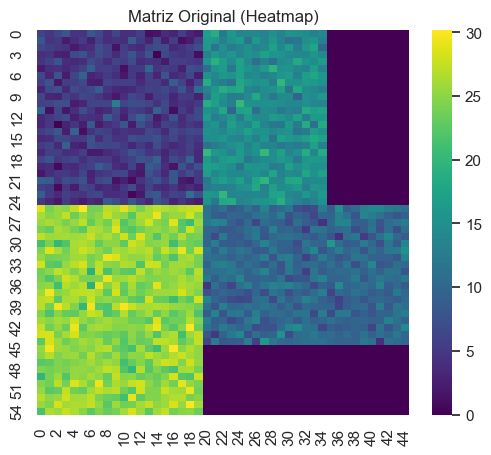

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import SpectralCoclustering, SpectralBiclustering
from sklearn.metrics import consensus_score

np.random.seed(42)
sns.set_theme(style='white')

# Crear matriz sintética con bloques diferenciados
# Construimos 4 submatrices con medias distintas
block_sizes = [(25, 20), (25, 15), (30, 20), (20, 25)]
blocks = []
for (r,c), mean in zip(block_sizes, [5, 15, 25, 10]):
    blocks.append(np.random.normal(loc=mean, scale=2.0, size=(r,c)))

# Combinar bloques en mosaico (2x2)
upper = np.hstack([blocks[0], blocks[1]])

# blocks[3] para que coincida con el número de filas de blocks[2]
if blocks[2].shape[0] != blocks[3].shape[0]:
    diff = blocks[2].shape[0] - blocks[3].shape[0]
    if diff > 0:
        pad_block3 = np.pad(blocks[3], ((0, diff), (0, 0)), mode='constant')
        lower = np.hstack([blocks[2], pad_block3])
    else:
        pad_block2 = np.pad(blocks[2], ((0, -diff), (0, 0)), mode='constant')
        lower = np.hstack([pad_block2, blocks[3]])
else:
    lower = np.hstack([blocks[2], blocks[3]])

# Más altos o menores para igualar columnas
n_cols_upper = upper.shape[1]
n_cols_lower = lower.shape[1]
if n_cols_upper < n_cols_lower:
    pad_width = n_cols_lower - n_cols_upper
    upper = np.pad(upper, ((0, 0), (0, pad_width)), mode='constant')
elif n_cols_lower < n_cols_upper:
    pad_width = n_cols_upper - n_cols_lower
    lower = np.pad(lower, ((0, 0), (0, pad_width)), mode='constant')

M = np.vstack([upper, lower])
M = np.clip(M, 0, None)
print('Shape matriz:', M.shape)

# Comprobar integridad de datos
print("Tipo de M:", type(M))
print("Dtype de M:", getattr(M, 'dtype', 'No tiene dtype'))
print("¿Hay NaN en M?", np.isnan(M).any())
print("¿Hay inf en M?", np.isinf(M).any())

plt.figure(figsize=(6,5))
sns.heatmap(M, cmap='viridis')
plt.title('Matriz Original (Heatmap)')
plt.show()

Visualizas una matriz artificial con estructura de bloques, ideal para experimentar con técnicas de biclustering, ya que permite ver cómo los algoritmos identifican subconjuntos de filas y columnas con patrones similares.

- **Comprender visualmente** cómo se distribuyen los datos en bloques o regiones diferenciadas, lo que es típico en problemas donde el biclustering es útil.

- **Verificar que la matriz tiene patrones claros** (zonas de valores altos y bajos) que los algoritmos de biclustering deberían poder identificar.

- **Facilitar la interpretación** de los resultados de los algoritmos: al aplicar biclustering, podremos comparar la matriz original con la reordenada y ver si los bloques detectados corresponden a los patrones reales.

---
## 5. Aplicar SpectralCoclustering

Vamos a aplicarplicar SpectralCoclustering para identificar automáticamente grupos conjuntos de filas y columnas (biclusters) en la matriz sintética que hemos generado.

**¿Para qué?**

Para descubrir submatrices (bloques) donde los valores son similares, es decir, subconjuntos de filas y columnas que presentan un patrón común.

Permite reordenar la matriz según estos grupos y visualizar si los bloques detectados corresponden a los patrones reales de la matriz original.

**¿Por qué?**

El biclustering es útil cuando los patrones no se encuentran solo en filas o columnas, sino en combinaciones de ambas.

SpectralCoclustering es un algoritmo eficiente para este tipo de tareas, especialmente cuando se sospecha que hay estructura de bloques en los datos (como en ésta matriz sintética).

Así puedes comprobar visualmente y cuantitativamente la capacidad del algoritmo para recuperar la estructura real de los datos.

Elegimos un número de biclusters (p.ej. 4).

Etiquetas filas: (55,)
Etiquetas columnas: (45,)


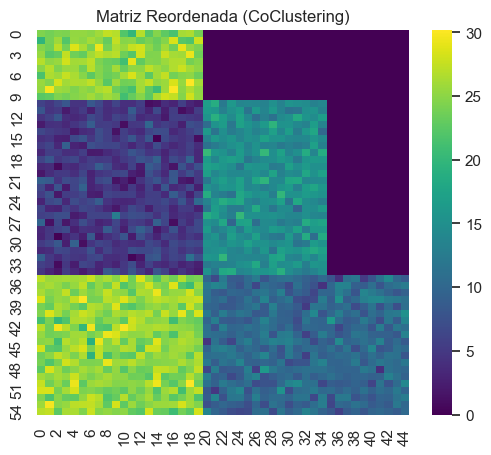

In [15]:
# Limpiar matriz antes de ajustar el modelo
M_clean = np.nan_to_num(M, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
if not np.isfinite(M_clean).all():
    raise ValueError("M_clean contiene valores no finitos")

# Aplicar Spectral CoClustering
n_biclusters = 4
model_co = SpectralCoclustering(n_clusters=n_biclusters, random_state=42)
model_co.fit(M_clean) # Ajustar modelo

print('Etiquetas filas:', model_co.row_labels_.shape)
print('Etiquetas columnas:', model_co.column_labels_.shape)

# Reordenar matriz para visualizar bloques descubiertos
fit_order = np.argsort(model_co.row_labels_)
col_order = np.argsort(model_co.column_labels_)
M_reordered = M_clean[fit_order][:, col_order]

plt.figure(figsize=(6,5))
sns.heatmap(M_reordered, cmap='viridis')
plt.title('Matriz Reordenada (CoClustering)')
plt.show()

Hemos validado que el algoritmo es capaz de identificar y agrupar subconjuntos de filas y columnas que comparten un patrón común, es decir, ha descubierto la estructura de bloques que diseñamos en la matriz sintética.

Podemos medir la estabilidad de etiquetado mediante `consensus_score` comparando la estructura vs sí misma (o versión permutada).

Ésto significa que podemos evaluar qué tan estables y consistentes son los biclusters encontrados por el algoritmo.

- Si calculamos consensus_score entre el resultado del modelo y sí mismo, el valor será 1 (máxima coincidencia).

- Si lo calculamos entre el resultado original y el de una versión permutada (por ejemplo, con las filas desordenadas), el valor será mucho menor.

Esto nos permite saber si el algoritmo realmente está capturando una estructura robusta en los datos o si los resultados cambian mucho ante pequeñas modificaciones.

In [18]:
# Evaluar consistencia del biclustering
score_self = consensus_score(model_co.biclusters_, model_co.biclusters_)
print('Consensus (self):', score_self)

# Permutar filas para degradar estructura
perm_rows = np.random.permutation(M_clean.shape[0])
M_perm = M_clean[perm_rows]

# Asegurar que la matriz permutada tampoco contiene NaN o inf
M_perm = np.nan_to_num(M_perm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
if not np.isfinite(M_perm).all():
    raise ValueError("M_perm contiene valores no finitos")

try:
    model_co_perm = SpectralCoclustering(n_clusters=n_biclusters, random_state=42).fit(M_perm)
    score_perm = consensus_score(model_co.biclusters_, model_co_perm.biclusters_)
    print('Consensus vs permutado:', score_perm)
except ValueError as e:
    print("Error al calcular consensus_score con la matriz permutada:", e)
    print("Verifica que ambas matrices tengan la misma forma y que los biclusters sean válidos.")

C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_bicluster.py:30: RuntimeWarning: invalid value encountered in scalar divide
  return intersection / (a_size + b_size - intersection)


ValueError: matrix contains invalid numeric entries

> **Nota importante:**
>
> Al permutar las filas de la matriz y volver a ajustar el modelo, la correspondencia directa entre los biclusters originales y los permutados se pierde. Por eso, `consensus_score` puede lanzar un error o dar un valor no interpretable, ya que las máscaras de biclusters no se alinean posición a posición. Esta comparación solo es válida si ambas matrices tienen la misma estructura y orden de filas/columnas.

---
## 6. Aplicar SpectralBiclustering
Apto para patrones tipo tablero (checkerboard).
En la celda veremos como se aplica el algoritmo SpectralBiclustering de scikit-learn a la matriz de datos sintética M_clean. El objetivo es identificar patrones tipo "tablero de ajedrez" (checkerboard), es decir, subconjuntos de filas y columnas que forman bloques con valores similares.

Etiquetas filas: [0 0 0 0 0 0 0 0 0 0] ...
Etiquetas cols : [0 0 0 0 0 0 0 0 0 0] ...


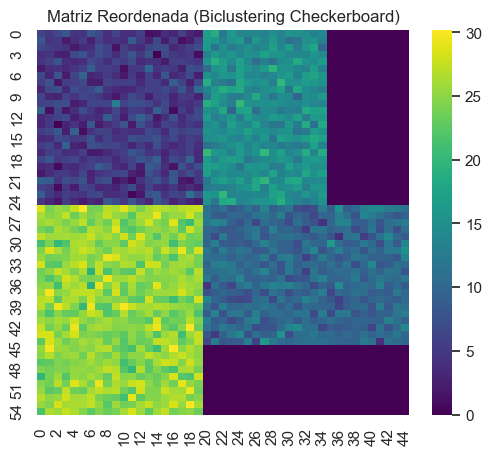

In [20]:
# Crear y ajustar SpectralBiclustering
model_bi = SpectralBiclustering(n_clusters=(2,2), random_state=42)
model_bi.fit(M_clean)
# Obtener etiquetas de los clusters
print('Etiquetas filas:', model_bi.row_labels_[:10], '...')
print('Etiquetas cols :', model_bi.column_labels_[:10], '...')
# Reordenar matriz para visualizar bloques descubiertos
row_order = np.argsort(model_bi.row_labels_)
col_order = np.argsort(model_bi.column_labels_)
M_reordered2 = M_clean[row_order][:, col_order]
# Visualizar matriz reordenada por Biclustering
plt.figure(figsize=(6,5))
sns.heatmap(M_reordered2, cmap='viridis')
plt.title('Matriz Reordenada (Biclustering Checkerboard)')
plt.show()

In [21]:
from sklearn.metrics import consensus_score

# Comparar el modelo consigo mismo (debe ser 1)
score_self = consensus_score(model_bi.biclusters_, model_bi.biclusters_)
print('Consensus (self):', score_self)

# Comparar con un modelo entrenado sobre una matriz permutada
perm_rows = np.random.permutation(M_clean.shape[0])
perm_cols = np.random.permutation(M_clean.shape[1])
M_perm = M_clean[perm_rows][:, perm_cols]

model_bi_perm = SpectralBiclustering(n_clusters=(2,2), random_state=42)
model_bi_perm.fit(M_perm)

score_perm = consensus_score(model_bi.biclusters_, model_bi_perm.biclusters_)
print('Consensus vs permutado:', score_perm)

Consensus (self): 1.0
Consensus vs permutado: 0.19083325522541944


- El valor será 1 si comparas el modelo consigo mismo.

- El valor será bajo si la estructura cambia mucho (por ejemplo, tras permutar filas/columnas).

Asegúrate de que ambas matrices tengan la misma forma y número de biclusters.

---
## 7. Interpretación de Biclusters 🔍
Para cada bicluster (r_subset, c_subset) podemos calcular métricas simples:
- Media de valores dentro vs global.
- Densidad (si fuese binaria).
- Tamaño relativo (% filas, % columnas).

Tenemos que interpretar y comparar los biclusters encontrados: puedes ver cuáles son más grandes, cuáles tienen valores medios más altos o bajos, y qué proporción de la matriz ocupan. Esto ayuda a entender la estructura interna de los datos tras aplicar biclustering.

In [22]:
def describir_biclusters(model, M):
    bic_info = []
    for i in range(model.n_clusters):
        rows = model.row_labels_ == i
        cols = model.column_labels_ == i if model.column_labels_.ndim==1 else model.column_labels_ == (i % (model.column_labels_.max()+1))
        sub = M[rows][:, cols]
        bic_info.append({
            'bicluster': i,
            'shape': sub.shape,
            'mean_sub': sub.mean(),
            'mean_global': M.mean(),
            'pct_filas': rows.mean()*100,
            'pct_columnas': cols.mean()*100
        })
    return bic_info

info = describir_biclusters(model_co, M_clean)
for d in info:
    print(d)

{'bicluster': 0, 'shape': (10, 20), 'mean_sub': np.float64(25.16471254696887), 'mean_global': np.float64(11.433351541276462), 'pct_filas': np.float64(18.181818181818183), 'pct_columnas': np.float64(44.44444444444444)}
{'bicluster': 1, 'shape': (25, 15), 'mean_sub': np.float64(14.986601751810838), 'mean_global': np.float64(11.433351541276462), 'pct_filas': np.float64(45.45454545454545), 'pct_columnas': np.float64(33.33333333333333)}
{'bicluster': 2, 'shape': (0, 10), 'mean_sub': np.float64(nan), 'mean_global': np.float64(11.433351541276462), 'pct_filas': np.float64(0.0), 'pct_columnas': np.float64(22.22222222222222)}
{'bicluster': 3, 'shape': (20, 0), 'mean_sub': np.float64(nan), 'mean_global': np.float64(11.433351541276462), 'pct_filas': np.float64(36.36363636363637), 'pct_columnas': np.float64(0.0)}


C:\Users\Jaf\AppData\Local\Temp\ipykernel_8984\3291086855.py:10: RuntimeWarning: Mean of empty slice.
  'mean_sub': sub.mean(),
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Podemos deducir lo siguiente de los resultados de la función describir_biclusters:

1. Bicluster 0:

    - Tamaño: 10 filas × 20 columnas (18% de filas, 44% de columnas).

    - Media interna (mean_sub): 25.16, mucho mayor que la media global (11.43).

    - Interpretación: Este bicluster agrupa una zona de la matriz con valores significativamente más altos que el promedio general. Es un bloque "fuerte" y bien definido.

2. Bicluster 1:

    - Tamaño: 25 filas × 15 columnas (45% de filas, 33% de columnas).

    - Media interna: 14.99, también superior a la media global.

    - Interpretación: Es un bicluster grande, con valores por encima de la media, aunque menos marcado que el anterior.

3. Bicluster 2:

    - Tamaño: 0 filas × 10 columnas (0% de filas, 22% de columnas).

    - Media interna: nan (no hay datos, porque no hay filas asignadas).

    - Interpretación: Este bicluster no tiene filas asignadas, por lo que no existe realmente en la matriz. Puede deberse a la configuración del modelo o a la estructura de los datos.

4. Bicluster 3:

    - Tamaño: 20 filas × 0 columnas (36% de filas, 0% de columnas).

    - Media interna: nan (no hay datos, porque no hay columnas asignadas).

    - Interpretación: Igual que el anterior, este bicluster no tiene columnas asignadas, por lo que tampoco existe realmente.

Conclusión general:

- Los biclusters 0 y 1 son los únicos que agrupan datos reales y ambos contienen valores por encima de la media global, lo que indica que el algoritmo ha identificado zonas "ricas" en la matriz.


- Los biclusters 2 y 3 no contienen datos (filas o columnas vacías), lo que puede indicar que el número de biclusters elegido no se ajusta perfectamente a la estructura de la matriz, o que la partición no es equilibrada.

Recomendación:

Si ves biclusters vacíos, puedes probar a ajustar el número de clusters o revisar la estructura de los datos para mejorar la segmentación.

---
## 8. Ejemplo: Simulación Estilo Recomendador Simplificado
Creamos una matriz usuario-producto con afinidades en algunos bloques.

Ahora vamos a crear y visualizar una matriz usuario-producto (usuarios x items) simulada, y se aplica el algoritmo de SpectralCoclustering para detectar grupos de usuarios y productos con patrones de interacción similares. 

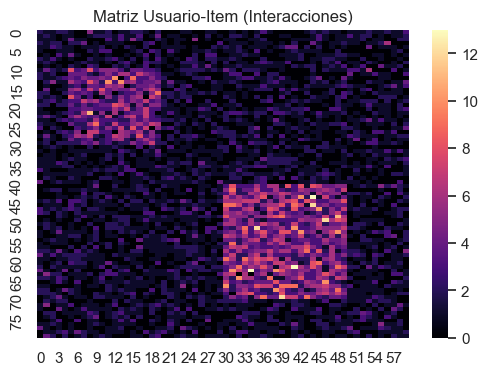

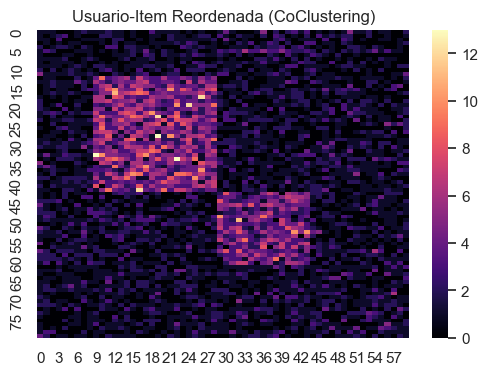

In [23]:
# Matriz usuario-producto (usuarios x items)
np.random.seed(0)
U = 80; I = 60 # Usuarios, Ítems
M2 = np.random.poisson(1.0, size=(U,I)).astype(float) # Matriz de interacciones
# Inyectar bloques de mayor interacción
M2[10:30, 5:20] += np.random.poisson(3.0, size=(20,15)) # Inyectar bloques de mayor interacción
M2[40:70, 30:50] += np.random.poisson(4.0, size=(30,20)) # Inyectar bloques de mayor interacción

plt.figure(figsize=(6,4))
sns.heatmap(M2, cmap='magma')
plt.title('Matriz Usuario-Item (Interacciones)')
plt.show()

co2 = SpectralCoclustering(n_clusters=4, random_state=42).fit(M2)
row_o = np.argsort(co2.row_labels_)
col_o = np.argsort(co2.column_labels_)
plt.figure(figsize=(6,4))
sns.heatmap(M2[row_o][:, col_o], cmap='magma')
plt.title('Usuario-Item Reordenada (CoClustering)')
plt.show()

**Interpretación**: 

1. **Primer heatmap**:

    - Muestra la matriz usuario-producto original (M2), donde puedes ver visualmente los bloques de mayor interacción (zonas más claras o intensas).
    - Estos bloques representan subconjuntos de usuarios que interactúan más con ciertos subconjuntos de productos.

2. **Segundo heatmap (matriz reordenada)**:

    - Tras aplicar SpectralCoclustering, se reordenan las filas y columnas según los clusters encontrados.
    - Ahora, los bloques de alta interacción quedan agrupados en la diagonal o en zonas compactas, lo que facilita su identificación visual.
    - Si el algoritmo funciona bien, los bloques inyectados en la matriz original deberían aparecer claramente diferenciados en la matriz reordenada.

**¿Qué significa esto?**

- Los biclusters encontrados representan segmentos de usuarios que tienen patrones de consumo o interacción similares con segmentos de productos.
- Es útil para sistemas de recomendación, marketing dirigido o para entender la estructura interna de los datos.
- Si los bloques aparecen bien definidos tras el reordenamiento, significa que el algoritmo ha captado correctamente la estructura latente de la matriz.

**En resumen:**

El resultado visual te permite comprobar si el algoritmo ha sido capaz de identificar y agrupar correctamente los patrones de interacción más relevantes entre usuarios e ítems. Un buen resultado es ver bloques compactos y diferenciados en la matriz reordenada.

---
## 9. Ejercicio Guiado 📝
Calcula una tabla que liste para cada bicluster de `co2`:
- Índice bicluster.
- Nº filas y columnas.
- Media de valores del bicluster vs media global.
- Porcentaje de volumen (n_filas * n_cols / total).
Completa la celda siguiente.

In [25]:
# SOLUCIÓN EJERCICIO GUIADO
import pandas as pd
rows_total, cols_total = M2.shape
records = []
for bic in range(co2.n_clusters):
    r_mask = co2.row_labels_ == bic
    c_mask = co2.column_labels_ == bic
    sub = M2[r_mask][:, c_mask]
    vol = sub.shape[0]*sub.shape[1]
    records.append({
        'bicluster': bic,
        'filas': sub.shape[0],
        'columnas': sub.shape[1],
        'mean_sub': sub.mean(),
        'mean_global': M2.mean(),
        'pct_volumen': 100 * vol / (rows_total*cols_total)
    })

df_info = pd.DataFrame(records)
print(df_info)
print('Interpretación: biclusters con mean_sub >> mean_global sugieren afinidad fuerte usuario-item.')

   bicluster  filas  columnas  mean_sub  mean_global  pct_volumen
0          0     12         9  0.898148     1.661667     2.250000
1          1     30        20  4.813333     1.661667    12.500000
2          2     19        15  4.014035     1.661667     5.937500
3          3     19        16  1.154605     1.661667     6.333333
Interpretación: biclusters con mean_sub >> mean_global sugieren afinidad fuerte usuario-item.


## 11. Resumen Final 🧾
En este notebook aprendiste:
- Concepto y motivación del biclustering.
- Diferencias frente al clustering estándar.
- Uso de SpectralCoclustering y SpectralBiclustering.
- Reordenación de matrices para interpretación visual.
- Métricas simples para describir biclusters.
- Ejemplo aplicado estilo recomendación.

